# Build a new modelgrid 

We can build a modelgrid from scratch. First, we must load libraries.

In [3]:
from pathlib import Path
import flopy
from flopy.utils.gridgen import Gridgen
from flopy.utils import GridIntersect, Raster

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# pd.options.mode.chained_assignment = None
data_path = Path("/modelgrid/build")

Then we will define the modelgrid. It has 20 rows and 15 columns and 1 layer. The variable grad contains the 

In [4]:
nrow = 20
ncol = 15
nlay = 1

grad = np.expand_dims(np.linspace(50, 100, nrow), axis=1)[::-1]
top = np.ones((nrow, ncol)) * grad
botm = np.zeros((nlay, nrow, ncol))
botm[0, :, :] = top - 50
delr = np.full((ncol,), 250)
delc = np.full((nrow,), 150)
ibound = np.ones((nlay, nrow, ncol))
ibound[0, 4:10, 4:8] = 0

modelgrid = flopy.discretization.StructuredGrid(
    delc,
    delr,
    top,
    botm,
    ibound,
)
print(modelgrid)
print(type(modelgrid))

xll:0.0; yll:0.0; rotation:0.0; units:undefined; lenuni:0
<class 'flopy.discretization.structuredgrid.StructuredGrid'>


In [5]:
print(grad)

[[100.        ]
 [ 97.36842105]
 [ 94.73684211]
 [ 92.10526316]
 [ 89.47368421]
 [ 86.84210526]
 [ 84.21052632]
 [ 81.57894737]
 [ 78.94736842]
 [ 76.31578947]
 [ 73.68421053]
 [ 71.05263158]
 [ 68.42105263]
 [ 65.78947368]
 [ 63.15789474]
 [ 60.52631579]
 [ 57.89473684]
 [ 55.26315789]
 [ 52.63157895]
 [ 50.        ]]


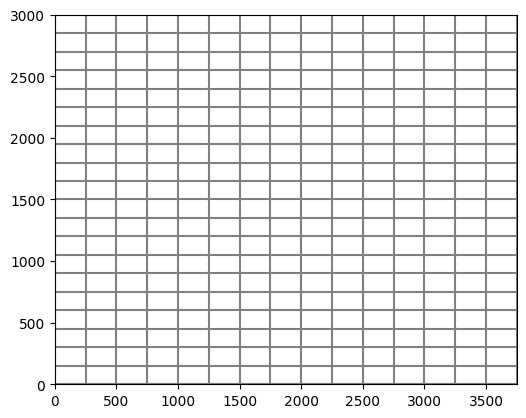

In [6]:



modelgrid.plot()

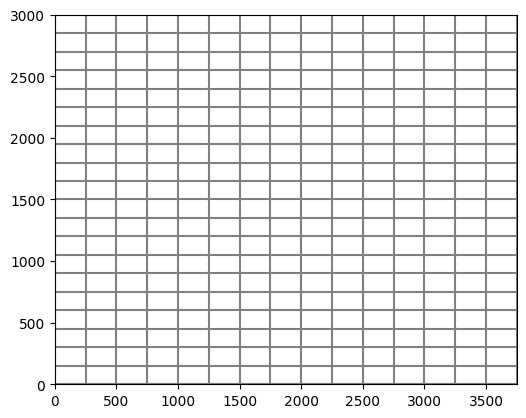

In [6]:



modelgrid.plot()

The modelgrid can be rotated and a coordinate system can be assigned. If you load a geotiff, this comes automatically.

In [7]:
xoff = 2345678
yoff = 1234567
angrot = -15
epsg = 32610  # utm zone 10N

modelgrid.set_coord_info(xoff=xoff, yoff=yoff, angrot=angrot, crs=epsg)

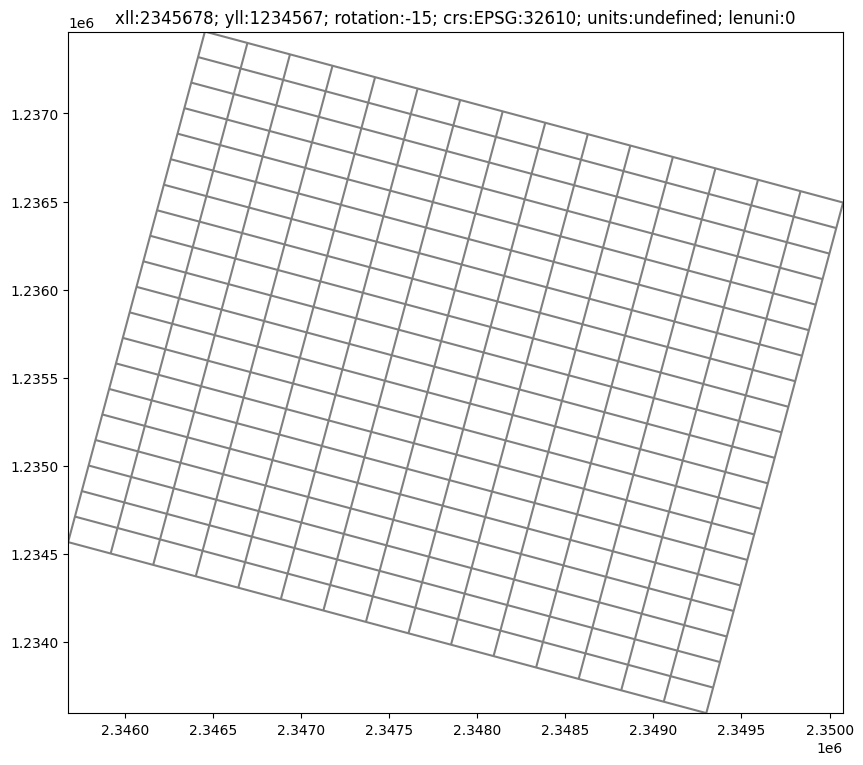

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
ax = modelgrid.plot(ax=ax)
plt.title(str(modelgrid));

One you have the grid, you can then retrieve the cell centers and the cell vertices.

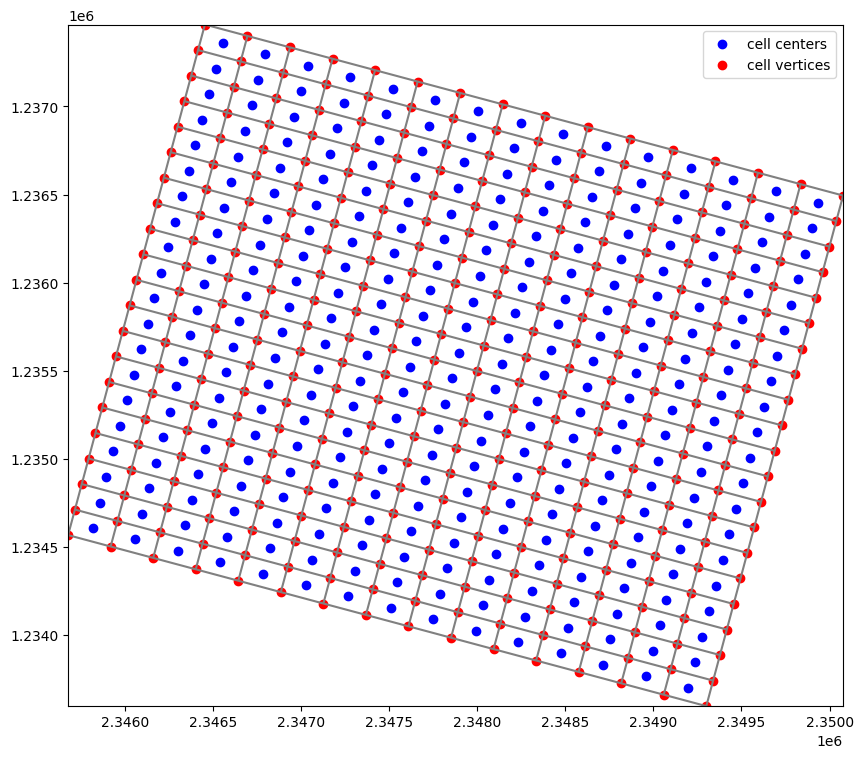

In [9]:
xc, yc = modelgrid.xcellcenters, modelgrid.ycellcenters
xv, yv = modelgrid.xvertices, modelgrid.yvertices

fig, ax = plt.subplots(figsize=(10, 10))
modelgrid.plot()
ax.scatter(xc.ravel(), yc.ravel(), c="b", label="cell centers")
ax.scatter(xv.ravel(), yv.ravel(), c="r", label="cell vertices")
plt.legend(loc=0);

You can also print these new variables.

In [10]:
print(xc,yc)

[[2346555.78643521 2346797.26789178 2347038.74934836 2347280.23080493
  2347521.7122615  2347763.19371807 2348004.67517464 2348246.15663122
  2348487.63808779 2348729.11954436 2348970.60100093 2349212.08245751
  2349453.56391408 2349695.04537065 2349936.52682722]
 [2346516.96357845 2346758.44503502 2346999.92649159 2347241.40794816
  2347482.88940473 2347724.37086131 2347965.85231788 2348207.33377445
  2348448.81523102 2348690.2966876  2348931.77814417 2349173.25960074
  2349414.74105731 2349656.22251388 2349897.70397046]
 [2346478.14072168 2346719.62217825 2346961.10363482 2347202.5850914
  2347444.06654797 2347685.54800454 2347927.02946111 2348168.51091769
  2348409.99237426 2348651.47383083 2348892.9552874  2349134.43674398
  2349375.91820055 2349617.39965712 2349858.88111369]
 [2346439.31786491 2346680.79932149 2346922.28077806 2347163.76223463
  2347405.2436912  2347646.72514778 2347888.20660435 2348129.68806092
  2348371.16951749 2348612.65097407 2348854.13243064 2349095.61388721

In [12]:
print(xv,yv)

[[2346454.45713531 2346695.93859188 2346937.42004845 2347178.90150502
  2347420.3829616  2347661.86441817 2347903.34587474 2348144.82733131
  2348386.30878789 2348627.79024446 2348869.27170103 2349110.7531576
  2349352.23461417 2349593.71607075 2349835.19752732 2350076.67898389]
 [2346415.63427854 2346657.11573511 2346898.59719169 2347140.07864826
  2347381.56010483 2347623.0415614  2347864.52301798 2348106.00447455
  2348347.48593112 2348588.96738769 2348830.44884427 2349071.93030084
  2349313.41175741 2349554.89321398 2349796.37467055 2350037.85612713]
 [2346376.81142178 2346618.29287835 2346859.77433492 2347101.25579149
  2347342.73724807 2347584.21870464 2347825.70016121 2348067.18161778
  2348308.66307435 2348550.14453093 2348791.6259875  2349033.10744407
  2349274.58890064 2349516.07035722 2349757.55181379 2349999.03327036]
 [2346337.98856501 2346579.47002158 2346820.95147816 2347062.43293473
  2347303.9143913  2347545.39584787 2347786.87730445 2348028.35876102
  2348269.84021759

## Ibound

A very important property of the model is the ibound array. This array fixes, which part of the model is active (1), which one is inactive (0) and which one has constant heads.

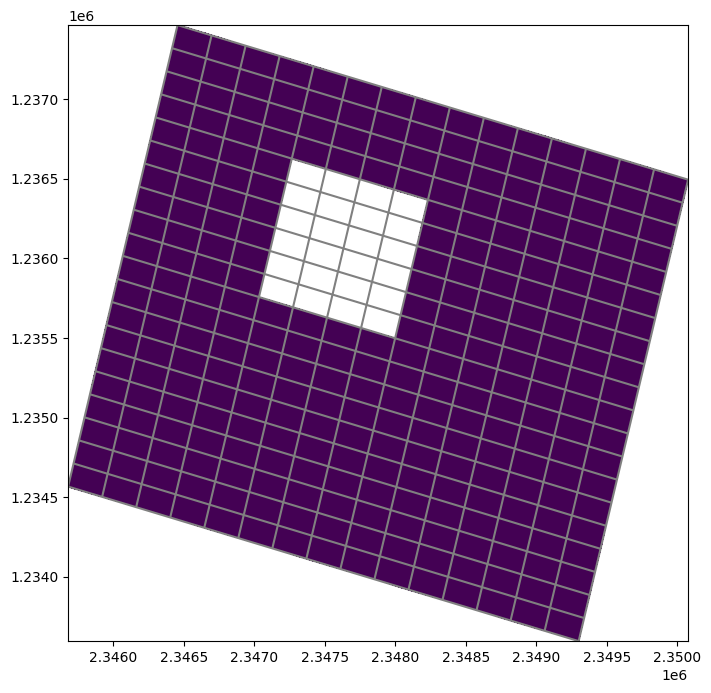

In [13]:
ibound = modelgrid.idomain

fig, ax = plt.subplots(figsize=(8, 8))
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid, ax=ax)
pmv.plot_grid()
pmv.plot_array(ibound, masked_values=[0,]);

We can also print ibound.

In [14]:
print(ibound)

[[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]]


This is good, because we can now modify ibound. By re-assigning new values. For this we need to understand arrays. We can select parts of the array by using indices.

In [15]:
ibound[0,0,0:5]

array([1., 1., 1., 1., 1.])

## Defining top and bottom of the model and then modifying it.

In the same manner we can retrieve the top, the bottom and other parts of the model.

In [16]:
top = modelgrid.top
botm = modelgrid.botm
delc = modelgrid.delc
delr = modelgrid.delr
top, botm, delc, delr

(array([[100.        , 100.        , 100.        , 100.        ,
         100.        , 100.        , 100.        , 100.        ,
         100.        , 100.        , 100.        , 100.        ,
         100.        , 100.        , 100.        ],
        [ 97.36842105,  97.36842105,  97.36842105,  97.36842105,
          97.36842105,  97.36842105,  97.36842105,  97.36842105,
          97.36842105,  97.36842105,  97.36842105,  97.36842105,
          97.36842105,  97.36842105,  97.36842105],
        [ 94.73684211,  94.73684211,  94.73684211,  94.73684211,
          94.73684211,  94.73684211,  94.73684211,  94.73684211,
          94.73684211,  94.73684211,  94.73684211,  94.73684211,
          94.73684211,  94.73684211,  94.73684211],
        [ 92.10526316,  92.10526316,  92.10526316,  92.10526316,
          92.10526316,  92.10526316,  92.10526316,  92.10526316,
          92.10526316,  92.10526316,  92.10526316,  92.10526316,
          92.10526316,  92.10526316,  92.10526316],
        [ 89